# 1. Hash Table

### 1.1 Class

In [ ]:
# Aqui temos 10 lista com "n" elementos dentro de cada lista
# quando a primeira posição de um lista esta ocupada o proximo item vai para a segunda posição.
# Exemplo: 11%10 = 1 (1º posição lista 2) | 21%10 = 1 (2º posição lista 2)
class HashTable:
    # O(n)----------------------------------------------------------------
    # O(n) pois cria "n" listas vazias
    def __init__(self, tamanho):
        self.tamanho = tamanho
        self.tabela = [[] for _ in range(tamanho)]  # cria o numero(tamanho) de listas vazias solicitadas

    # O(1)----------------------------------------------------------------
    # transforma a chave em um índice válido do array (45 % 10 = 5 posição)
    def _funcao_hash(self, chave):
        return chave % self.tamanho

    # O(1) ou O(n)--------------------------------------------------------
    # insere um novo valor caso ele não exista, se existir atualiza
    def inserir(self, chave, valor):
        # calcula o índice
        index= self._funcao_hash (chave)
        bucket = self.tabela [index]

        # verificar se a chave já existe e atualização do valor
        for i, (chave_existente, _) in enumerate (bucket):
            if chave_existente == chave:
                bucket[i] = (chave, valor)
                return
        # se a chave não existe, adicionar o novo par chave-valor no bucket
        bucket.append((chave, valor))

    # O(1) ou O(n)--------------------------------------------------------
    # busca um valor dentro do bucket/tabela
    def buscar(self, chave):
        # calcula o índice
        index= self._funcao_hash (chave)
        bucket = self.tabela [index]
        # procurar pela chave e retornar o valor correspondente
        for chave_existente, valor in bucket:
            if chave_existente == chave:
                return valor

        return None # chave não encontrada!

    # O(1) ou O(n)--------------------------------------------------------
    # remove um valor dentro do bucket/tabela
    def remover (self, chave):
        # calcula o índice
        index= self._funcao_hash (chave)
        bucket = self.tabela [index]
        # procurar pela chave no bucket e remove elemento se encontrar
        for i, (chave_existente, _) in enumerate (bucket):
            if chave_existente == chave:
                del bucket[i]

        return None # chave não encontrada

### 1.2 Tests

In [ ]:
# EXEMPLO SEM COLIÇÕES:
hash_table = HashTable(10)

hash_table.inserir (11, "Alice")   # 11 % 10 = 1
hash_table.inserir (45, "Paula")   # 45 % 10 = 5
hash_table.inserir (58, "Helena")  # 58 % 10 = 8

print(hash_table.tabela)

[[], [(11, 'Alice')], [], [], [], [(45, 'Paula')], [], [], [(58, 'Helena')], []]


In [ ]:
# EXEMPLO COM COLIÇÕES:
hash_table.inserir (11, "Alice")   # 11 % 10 = 1
hash_table.inserir (15, "Pedro")   # 15 % 10 = 5  pedro e maria (mesma lista)
hash_table.inserir (35, "Maria")   # 35 % 10 = 5  pedro e maria (mesma lista)
hash_table.inserir (42, "João")    # 42 % 10 = 2

print(hash_table.tabela)

[[], [(11, 'Alice')], [(42, 'João')], [], [], [(45, 'Paula'), (15, 'Pedro'), (35, 'Maria')], [], [], [(58, 'Helena')], []]


In [ ]:
# REMOVER ITEM
print(hash_table.buscar(45))
hash_table.remover(45)
print(hash_table.tabela)

Paula
[[], [(11, 'Alice')], [(42, 'João')], [], [], [(15, 'Pedro'), (35, 'Maria')], [], [], [(58, 'Helena')], []]


# 2. Detectar Memoria

In [ ]:
# permite obter o tamanho (em bytes) de um objeto
import sys

# Encontra recursivamente o tamanho total (profundo) de um objeto em bytes
def get_deep_size(obj, seen=None):
    # obj  -> objeto informado
    # seen -> conjunto usado para evitar loop infinito
    #         (caso haja referências circulares entre objetos)

    # Se see == None, cria um conjunto vazio
    if seen is None:
        seen = set()

    obj_id = id(obj)    # identificador único de objeto na memória

    # Se esse objeto já foi contado antes, retorna 0 (evitando contar novamente)
    if obj_id in seen:
        return 0
    seen.add(obj_id)            # Marca o objeto como já visitado

    size = sys.getsizeof(obj)   # Iniicia com o tamanho "superficial" do objeto.

    # Caso1: Se for um dictionary(dict)
    if isinstance(obj, dict):
        # soma o tamanho de cada chave
        size += sum(get_deep_size(k, seen) for k in obj.keys())
        # soma o tamanho de cada valor
        size += sum(get_deep_size(v, seen) for v in obj.values())
    # Caso 2: Se for iteravel (lista, tupla, set ,etc ...))
    # mas NÃO for string ou bytes (para evitar contar caractere por caractere)
    elif hasattr(obj, '__iter__') and not isinstance(obj, (str, bytes, bytearray)):
        # soma o tamanho profundo de cada elemento do iterável
        size += sum(get_deep_size(o, seen) for o in obj)

    return size # FINAL = retorna o valor acumulado

In [ ]:
# EXEMPLO
# tentar esttimar quantos bytes a hash_table ocupa em memória incluindo:
# 1. o objeto HashTable
# 2. atributos internos (tamanho, tabela)
# 3. a lista de buckets
# 4. as listas dentro (buckets)
# 5. as tuplas (chave, valor)
# 6. as strings (valores como "Alice")
memoria_usada = get_deep_size(hash_table)
print(f"Memória usada pela tabela hash: {memoria_usada} bytes")

Memória usada pela tabela hash: 48 bytes


#
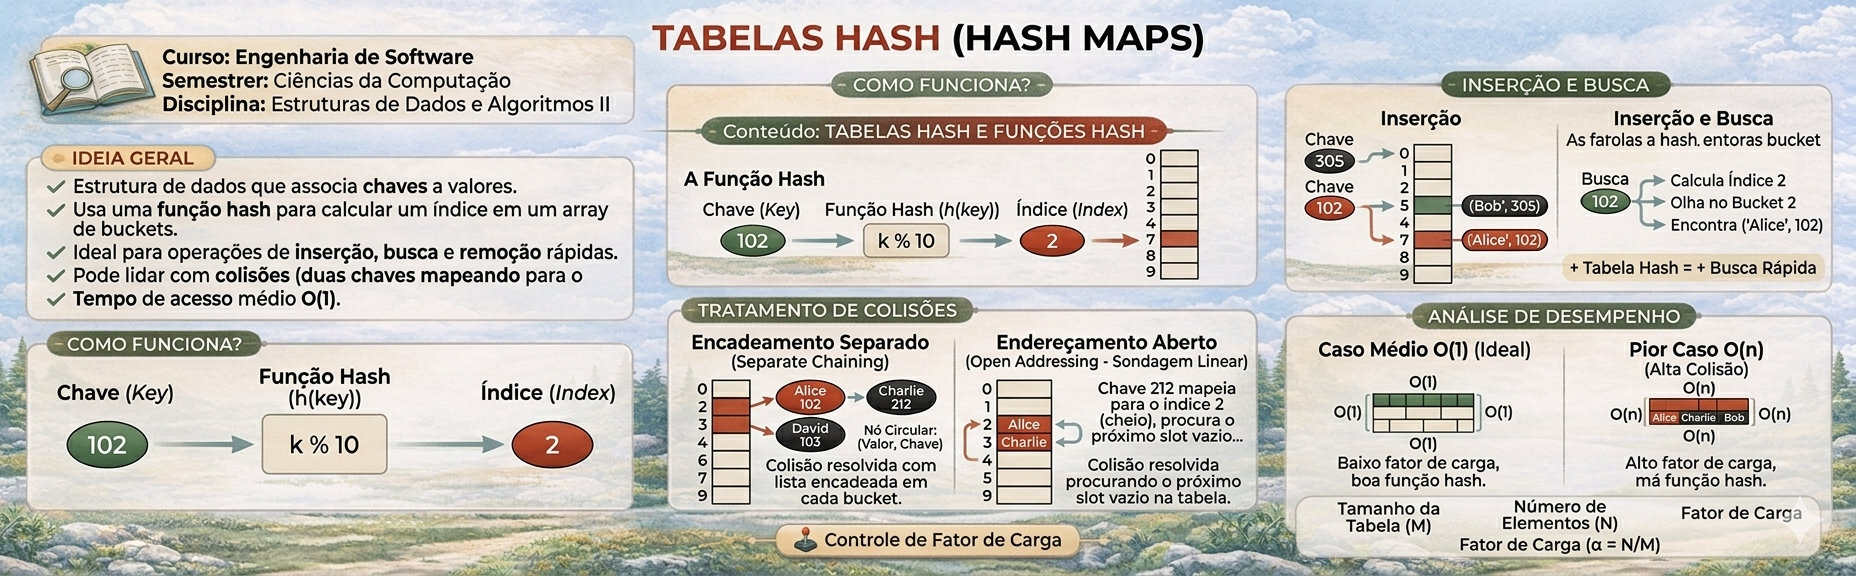